imagenes

Text(0.5, 1.0, 'Canal Azul')

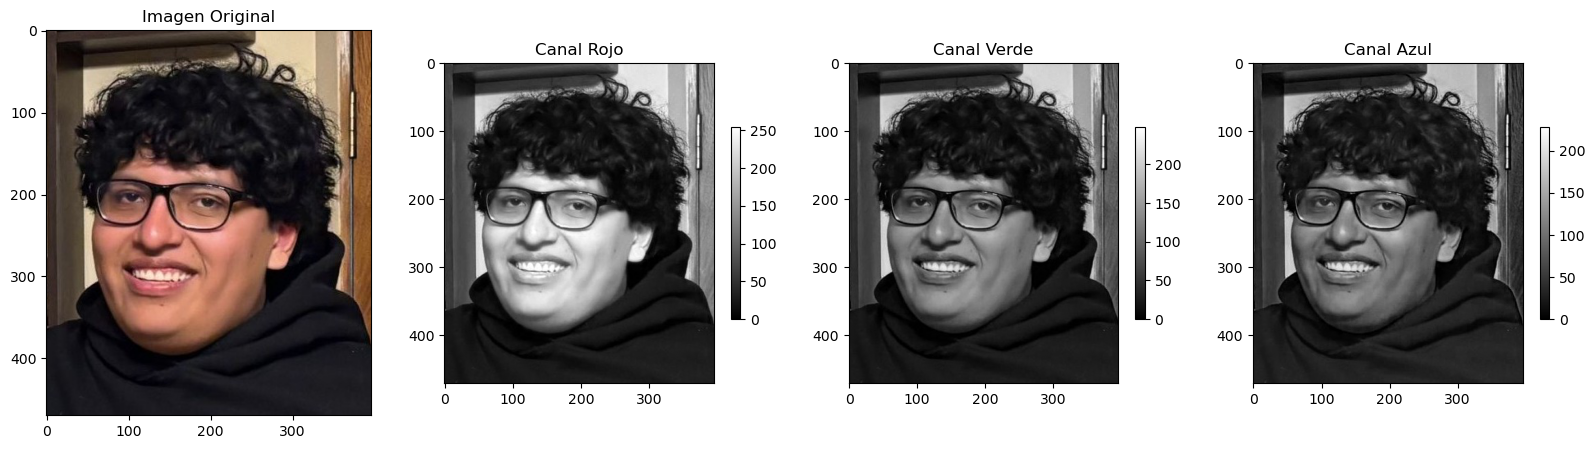

In [1]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('chanki.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(img_rgb)
axs[0].set_title('Imagen Original')

fig_img=axs[1].imshow(img_rgb[...,0], cmap='gray')
fig.colorbar(fig_img, ax=axs[1], shrink=0.5)
axs[1].set_title('Canal Rojo')

fig_img=axs[2].imshow(img_rgb[...,1], cmap='gray')
fig.colorbar(fig_img, ax=axs[2], shrink=0.5)
axs[2].set_title('Canal Verde')

fig_img=axs[3].imshow(img_rgb[...,2], cmap='gray')
fig.colorbar(fig_img, ax=axs[3], shrink=0.5)
axs[3].set_title('Canal Azul')

In [2]:
img_rgb[:3,:3,:]

array([[[75, 62, 54],
        [61, 48, 40],
        [60, 47, 39]],

       [[77, 64, 56],
        [63, 50, 42],
        [62, 49, 41]],

       [[73, 60, 52],
        [60, 47, 39],
        [61, 48, 40]]], dtype=uint8)

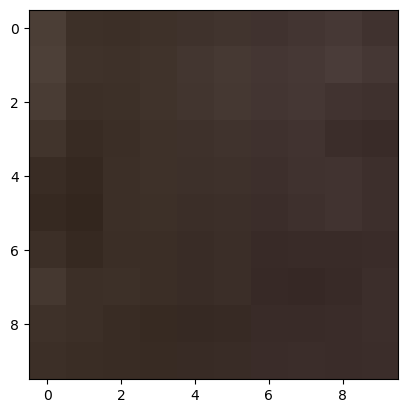

In [3]:
#para recortar una imagen
plt.imshow(img_rgb[:10,:10,:])

In [4]:
#GUARDAR CON OPENCV
cv2.imwrite('imagen.png',img_rgb)
#GUARDAR CON PYPLOT
plt.imsave('imagen_nueva.png', cv2.cvtColor(img_rgb,cv2.COLOR_BGR2RGB))

Ejercicios para generar una imagen

<function matplotlib.pyplot.show(close=None, block=None)>

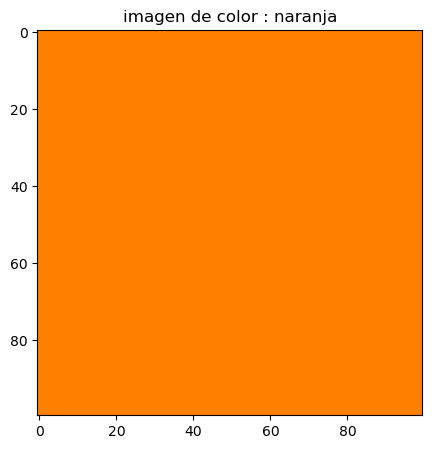

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize']=[10,5]
size_imagen=100
R=np.ones((size_imagen,size_imagen))*255
G=np.ones((size_imagen,size_imagen))*128
B=np.ones((size_imagen,size_imagen))*0

imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('imagen de color : naranja')
plt.show

escala de grises y profundidad de color

profundidad del color : uint16


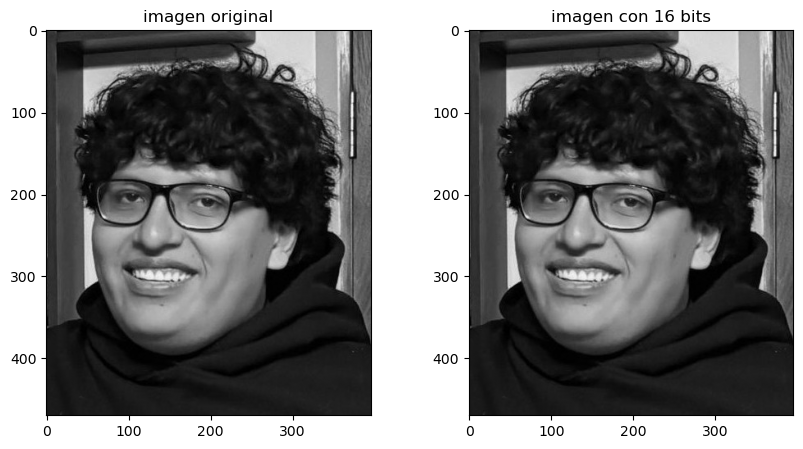

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img=cv2.imread('chanki.jpg',cv2.IMREAD_GRAYSCALE)
#valores iniciales de proginidad del color
original= img.dtype
#transformando img a 16 bits
img16bits= np.uint16(img)
img_new=img16bits.dtype
print('profundidad del color :', img_new)
#guardado con cv2
#guardado con pyplot

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('imagen original')
plt.imshow(img16bits,cmap='gray')

plt.subplot(1,2,2)
plt.title('imagen con 16 bits')
plt.imshow(img16bits,cmap='gray')

rgb

Text(0.5, 1.0, 'canal value')

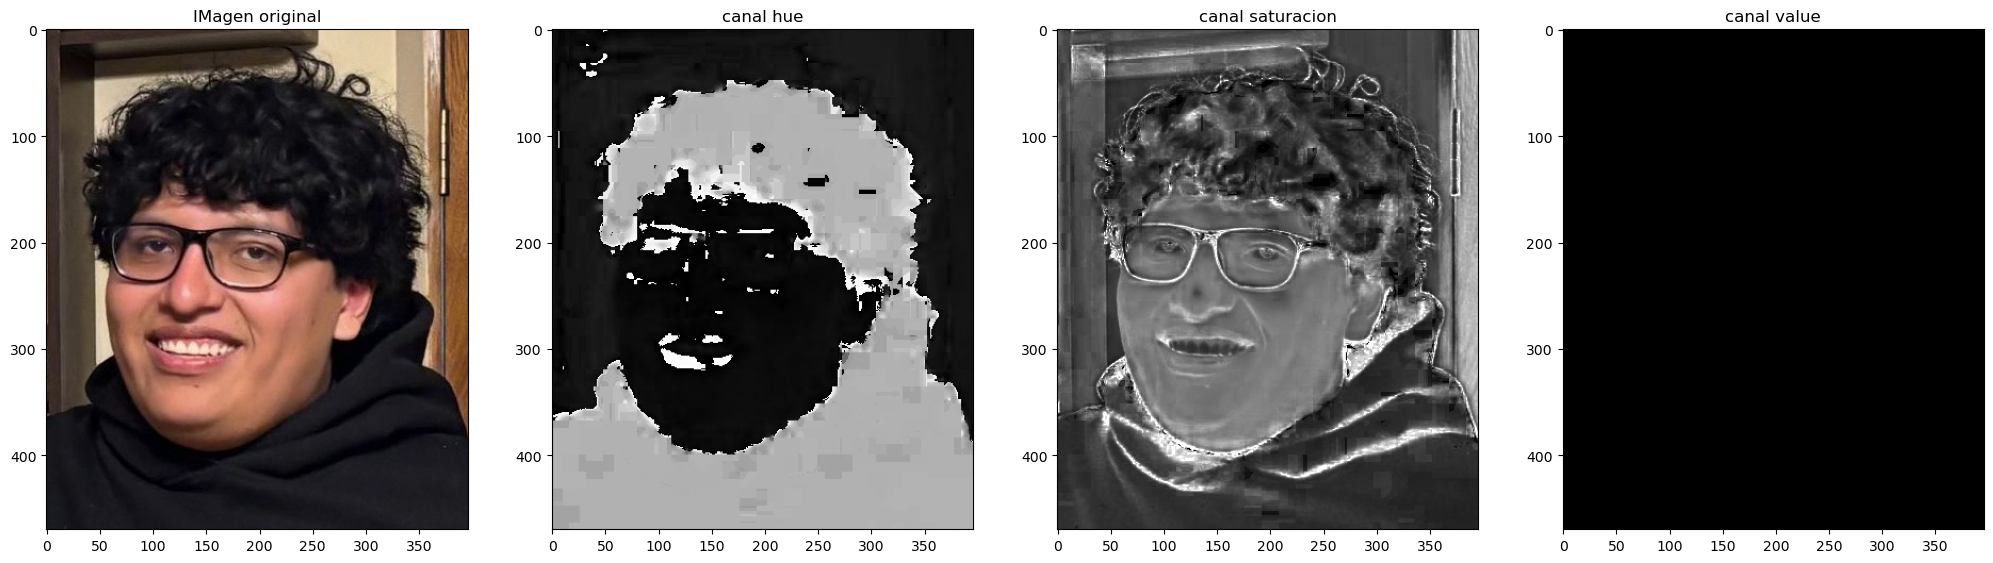

In [7]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np
imagen1=cv2.imread('chanki.jpg')
img=cv2.cvtColor(imagen1,cv2.COLOR_BGR2RGB)
def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img/255.
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img,axis=2)
    maxValue = np.amax(img,axis=2)
    minChannel = np.argmin(img,axis=2)
    minValue = np.amin(img,axis=2)
    #value 
    new_img[...,2] = maxValue

    #saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j]==0:
                new_img[i,j,1] = 0
            elif maxValue[i,j] != 0:
                new_img[i,j,1] = (new_img[i,j,2]-minValue[i,j])/new_img[i,j,2]

    #hue 
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if sum(img[i,j,...])/3 == img[i,j,0]:
                new_img[i,j,0] = 0
            elif maxChannel[i,j] == 0: #R 
                new_img[i,j,0] = 60 * ((img[i,j,1]-img[i,j,2])/(new_img[i,j,2]-minValue[i,j]))
            elif maxChannel[i,j] == 1: #G
                new_img[i,j,0] = 120 + 60 * (img[i,j,2]-img[i,j,0])/(new_img[i,j,2]-minValue[i,j])
            elif maxChannel[i,j] == 2: #B
                new_img[i,j,0] = 240 + 60 * (img[i,j,0]-img[i,j,1])/(new_img[i,j,2]-minValue[i,j])

        img2= new_img[...,0] < 0
        new_img[img2,0]   =  new_img[img2,0] + 360
    return new_img

hsv_img=RGB2HSV(img)
fig,axs=plt.subplots(1,4,figsize=(25,10))
axs[0].imshow(img)
axs[0].set_title('IMagen original')
fig_img=axs[1].imshow(hsv_img[...,0],cmap='gray',vmin=0,vmax=360)
axs[1].set_title('canal hue')
fig_img=axs[2].imshow(hsv_img[...,1],cmap='gray',vmin=0,vmax=1)
axs[2].set_title('canal saturacion')
fig_img=axs[3].imshow(hsv_img[...,2],cmap='gray',vmin=0,vmax=360)
axs[3].set_title('canal value')

RGB y HSV

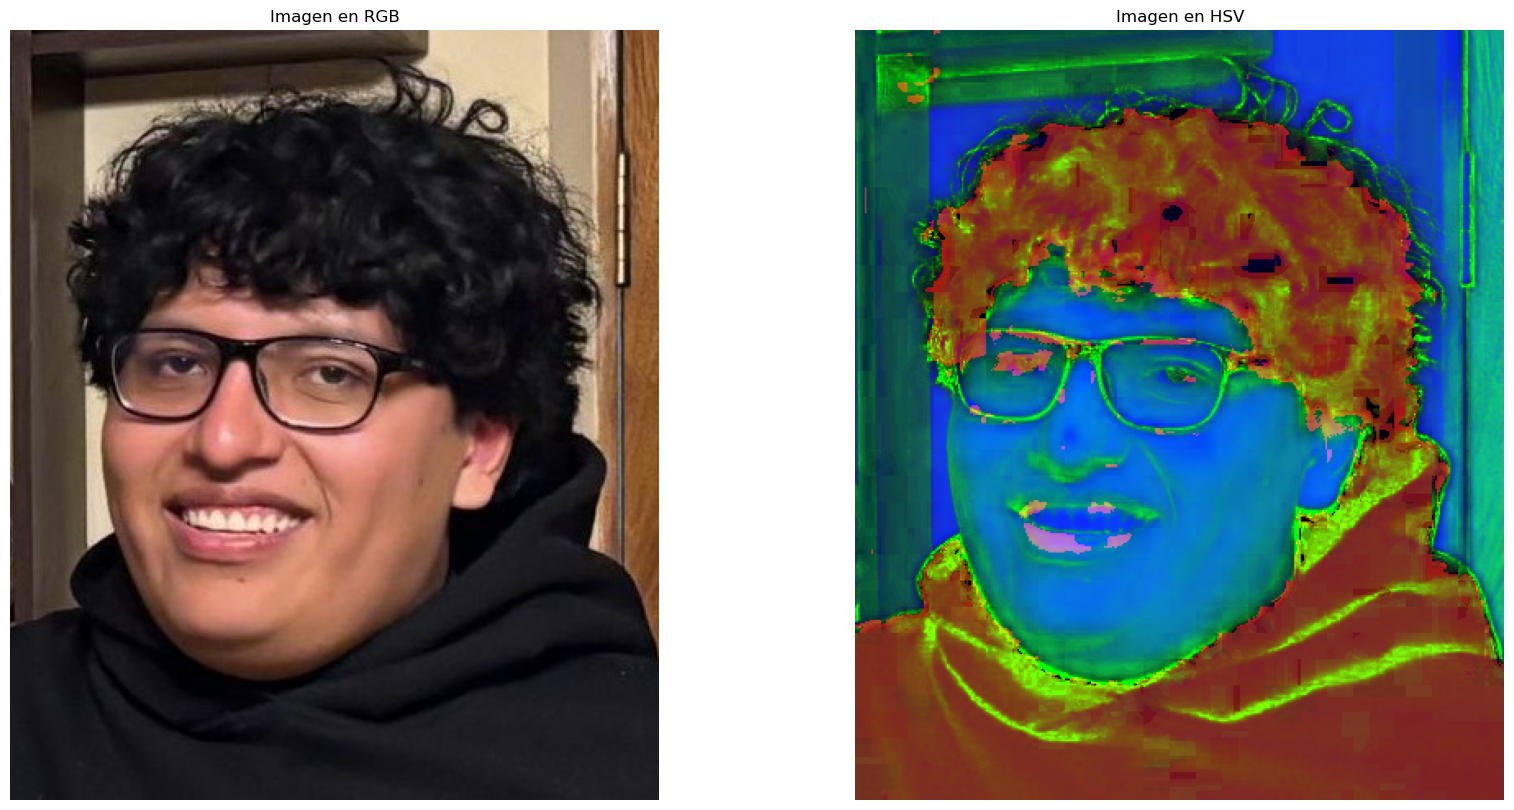

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rgb = cv2.cvtColor(cv2.imread('chanki.jpg', cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))

axs[0].imshow(img_rgb)
axs[0].set_title("Imagen en RGB")
axs[0].axis("off")

axs[1].imshow(img_hsv)
axs[1].set_title("Imagen en HSV")
axs[1].axis("off")


plt.show()

3

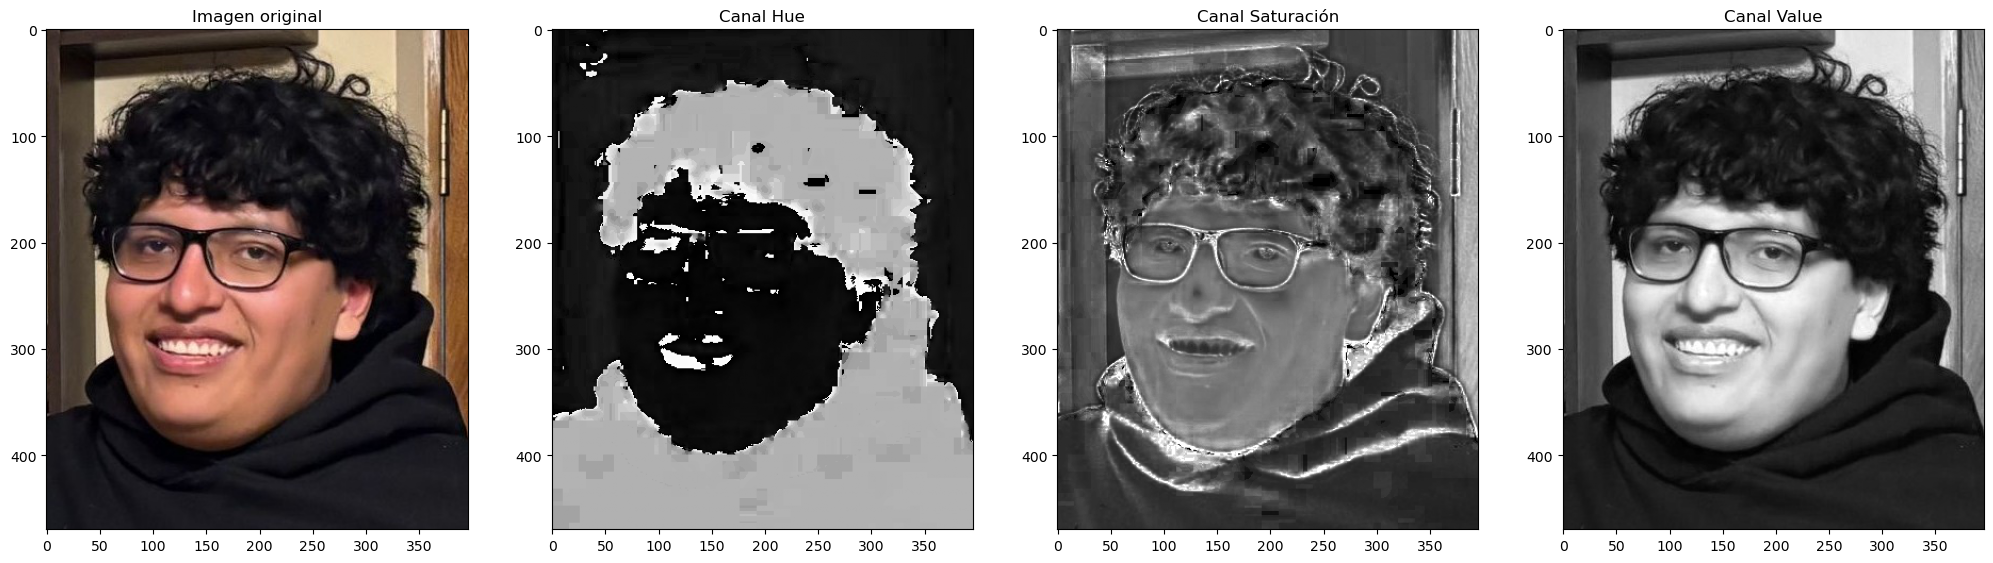

In [11]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np

imagen1 = cv2.imread('chanki.jpg')
img = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)

def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img / 255
    new_img = np.zeros_like(img)

    maxChanel = np.argmax(img, axis=2)
    maxValue = np.amax(img, axis=2)
    minValue = np.amin(img, axis=2)

    # Value
    new_img[...,2] = maxValue

    # Saturación
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] == 0:
                new_img[i,j,1] = 0
            else:
                new_img[i,j,1] = (maxValue[i,j] - minValue[i,j]) / maxValue[i,j]

    # Hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] == minValue[i,j]:
                new_img[i,j,0] = 0
            elif maxChanel[i,j] == 0:  # R
                new_img[i,j,0] = 60 * ((img[i,j,1] - img[i,j,2]) / (maxValue[i,j] - minValue[i,j]))
            elif maxChanel[i,j] == 1:  # G
                new_img[i,j,0] = 120 + 60 * ((img[i,j,2] - img[i,j,0]) / (maxValue[i,j] - minValue[i,j]))
            elif maxChanel[i,j] == 2:  # B
                new_img[i,j,0] = 240 + 60 * ((img[i,j,0] - img[i,j,1]) / (maxValue[i,j] - minValue[i,j]))

    # Ajustar negativos
    new_img[...,0][new_img[...,0] < 0] += 360

    return new_img


hsv_img = RGB2HSV(img)

fig, axs = plt.subplots(1,4,figsize=(25,10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')

axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')

plt.show()